# CottonVerse: Cotton leaf disease classification + Grad-CAM (XCottL-FebViT / LEViT)

Reproduction of the minimal inference path from:
**"Explainable transformer framework for fast cotton leaf diagnostics and fabric defect detection."**
(Swapno et al., *iScience* 29(2):114411, 2025, DOI [10.1016/j.isci.2025.114411](https://doi.org/10.1016/j.isci.2025.114411))

Author code: [rezaul-h/CottonVerse](https://github.com/rezaul-h/CottonVerse) @ commit `ad0ba908931fd283173644b7f28b22a37ecd8af8` (MIT license). This notebook follows the author's `utils.py` (`load_model`, `predict_with_cam`) line for line.

**Scope (executed):** one cotton leaf image → 8-class CottonLeafNet LEViT (`levit_128s`) prediction with class probabilities and a Grad-CAM attention overlay. This is a single-example demonstration, **not** a verification of the paper's dataset-level 10-fold results (augmented F1 99.80 ± 0.62 for CottonLeafNet).

**日本語の概要:** 本ノートブックは CottonVerse の推論コード（`utils.py`）に忠実に従い、コットン葉画像 1 枚を 8 クラスに分類し、Grad-CAM による注視マップを表示します。単一サンプルのデモであり、論文の 10 分割交差検証（拡張データで F1 99.80 ± 0.62）の再検証ではありません。

**How to run:** `Runtime → Run all`. Works on **CPU or T4 GPU** (CPU is recommended: the model is only 28 MB and the demo runs in well under a minute on CPU). The notebook detects the allocated hardware and follows the author's device logic.

**Expected duration:** ~2–4 minutes including downloads (~30 MB: model weights + one image + small pip packages).


## 1. Environment setup

The author's `requirements.txt` lists `pytorch-grad-cam`; that project is now published on PyPI as **`grad-cam`** (the import name is still `pytorch_grad_cam`, verified on the Colab runtime). We install it plus `kagglehub` for the sample image. Torch, torchvision, timm, pillow, numpy and OpenCV are preinstalled on Colab.

**Setup:** 著者の `requirements.txt` の `pytorch-grad-cam` は現在 PyPI では `grad-cam` という名前に改名されています（import 名は `pytorch_grad_cam` のまま）。

In [ ]:
%pip install -q grad-cam kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.3 MB/s eta 0:00:00


  Installing build dependencies ... done


  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Dependency / runtime check

Verify the framework versions actually used for this run and detect the device exactly as the author's `utils.py` does (`if torch.cuda.is_available(): ... .cuda()`).

**使用環境の確認:** 実行時の torch/timm のバージョンと、割り当てられたデバイス（CPU または T4 GPU）を表示します。

In [ ]:
import torch, timm, torchvision, sys, platform
print("python", sys.version.split()[0], "| torch", torch.__version__, "| timm", timm.__version__, "| torchvision", torchvision.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU allocated; running on CPU (sufficient for this 28 MB model).")
print("device =", device)

python 3.13.15 | torch 2.11.0+cu130 | timm 1.0.29 | torchvision 0.26.0+cu130
GPU: Tesla T4
device = cuda


## 3. Model weights (pinned download + integrity check)

Download the author-shipped CottonLeafNet weight from the pinned commit and verify its byte size and SHA-256 before use. Expected: 28,337,546 bytes; SHA-256 `8f12aae2…391bd` (verified on 2026-10-05; git blob `0313c7e0…f38af0aa`).

**重みのダウンロード:** 著者リポジトリの固定コミットから CottonLeafNet 用重み（28.3 MB）を取得し、サイズと SHA-256 を検証します。

In [ ]:
import urllib.request, hashlib, pathlib

WEIGHT_URL = ("https://raw.githubusercontent.com/rezaul-h/CottonVerse/"
              "ad0ba908931fd283173644b7f28b22a37ecd8af8/model/CottonLeafNet_levit_model.pth")
WEIGHT_PATH = pathlib.Path("/content/CottonLeafNet_levit_model.pth")

urllib.request.urlretrieve(WEIGHT_URL, WEIGHT_PATH)
blob = WEIGHT_PATH.read_bytes()
assert len(blob) == 28_337_546, f"unexpected weight size: {len(blob)}"
sha = hashlib.sha256(blob).hexdigest()
print("bytes:", len(blob))
print("sha256:", sha)
assert sha == "8f12aae29b37c39682ab15c2e8f3db034bdd9a543de14d8bba31920d378391bd", "checksum mismatch"
print("weight integrity OK")

bytes: 28337546
sha256: 8f12aae29b37c39682ab15c2e8f3db034bdd9a543de14d8bba31920d378391bd
weight integrity OK


## 4. Load the LEViT model

Build `timm`'s `levit_128s` with the 8-class CottonLeafNet head and load the state dict, exactly as the author's `load_model` in `utils.py` (including `map_location='cpu'` then optional device move). The 8 class names are taken verbatim from `app.py`.

**モデルの読み込み:** `utils.py` の `load_model` に従い、`levit_128s`（8 クラス）に重みを厳密に読み込みます。クラス名は `app.py` からそのまま引用。

In [ ]:
class_names = ['Aphids', 'Army Worm', 'Bacterial Blight', 'Cotton Boll Rot',
               'Green Cotton Boll', 'Healthy', 'Powdery Mildew', 'Target Spot']

model = timm.create_model("levit_128s", pretrained=False, num_classes=len(class_names))
model.load_state_dict(torch.load(WEIGHT_PATH, map_location='cpu'))
model.eval()
model = model.to(device)
print("loaded levit_128s with", len(class_names), "classes ->", device)

loaded levit_128s with 8 classes -> cuda


## 5. Sample input: one cotton leaf image (author's CottonLeafNet dataset)

Download a single, deterministic sample image — `CottonLeafNet/Healthy/n (37).jpg` (83,397 bytes) from the author's public Kaggle dataset `rezaullhaque/cottonleafnet-dataset` — via `kagglehub` (public, no login needed). `kagglehub`'s `path=` argument fetches only this one file.

**入力サンプル:** 著者の公開 Kaggle データセットから 1 枚の決定論的サンプル（Healthy クラスの原画像）を単一ファイル取得します。

In [ ]:
import kagglehub, os

SAMPLE_REL = "CottonLeafNet/Healthy/n (37).jpg"
image_path = kagglehub.dataset_download("rezaullhaque/cottonleafnet-dataset", path=SAMPLE_REL)
print(image_path, os.path.getsize(image_path), "bytes")

  0%|          | 0.00/81.4k [00:00<?, ?B/s]

100%|██████████| 81.4k/81.4k [00:00<00:00, 848kB/s]

/root/.cache/kagglehub/datasets/rezaullhaque/cottonleafnet-dataset/versions/1/CottonLeafNet/Healthy/n (37).jpg 83397 bytes


Preview the actual input image before the scientific analysis (dimensions shown from the real file).

**入力画像のプレビュー:** 解析前に実際の入力画像とその寸法を表示します。

input image: (800, 640) RGB - CottonLeafNet/Healthy/n (37).jpg


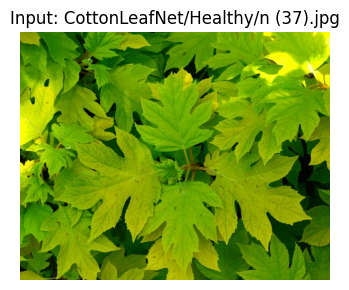

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img_pil = Image.open(image_path).convert("RGB")
print("input image:", img_pil.size, img_pil.mode, "-", SAMPLE_REL)
plt.figure(figsize=(4, 4))
plt.imshow(img_pil)
plt.title(f"Input: {SAMPLE_REL}")
plt.axis("off")
plt.show()

## 6. Prediction + Grad-CAM (author's `predict_with_cam`)

Run the author's exact preprocessing (resize to 224×224, ToTensor, Normalize([0.5])), forward pass, argmax class, and Grad-CAM against the author's target layer `model.stem.conv4.linear`. The overlay uses `show_cam_on_image` as in `utils.py`.

**推論と Grad-CAM:** `utils.py` の `predict_with_cam` をそのまま実行します（前処理・ターゲット層 `stem.conv4.linear`・`show_cam_on_image` を含む）。

In [ ]:
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

img_tensor = transform(img_pil)
input_tensor = img_tensor.unsqueeze(0)
rgb_img = ((img_tensor * 0.5) + 0.5).permute(1, 2, 0).numpy()

if torch.cuda.is_available():
    input_tensor = input_tensor.cuda()

with torch.no_grad():
    output = model(input_tensor)
    probs = torch.nn.functional.softmax(output[0], dim=0)
    class_idx = probs.argmax().item()

target_layers = [model.stem.conv4.linear]
cam = GradCAM(model=model, target_layers=target_layers)
grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(class_idx)])[0]
cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

predicted_class = class_names[class_idx]
probabilities_percent = [round(p.item() * 100, 1) for p in probs]
print("predicted:", predicted_class)
print("probabilities (%):", dict(zip(class_names, probabilities_percent)))

predicted: Healthy
probabilities (%): {'Aphids': 0.1, 'Army Worm': 0.0, 'Bacterial Blight': 0.1, 'Cotton Boll Rot': 0.1, 'Green Cotton Boll': 0.1, 'Healthy': 99.4, 'Powdery Mildew': 0.1, 'Target Spot': 0.1}


## 7. Results: input vs. Grad-CAM overlay + probability table

Show the input image next to its Grad-CAM overlay (the red regions are what drove the decision), followed by the full class-probability table and a bar chart. This graph is an additional visualization created for this notebook (not an author figure); the numeric table is the author code's actual output.

**結果表示:** 入力画像と Grad-CAM のオーバーレイ、クラス確率の表と棒グラフ。棒グラフは本ノートブック用に追加した可視化であり、著者の図ではありません。

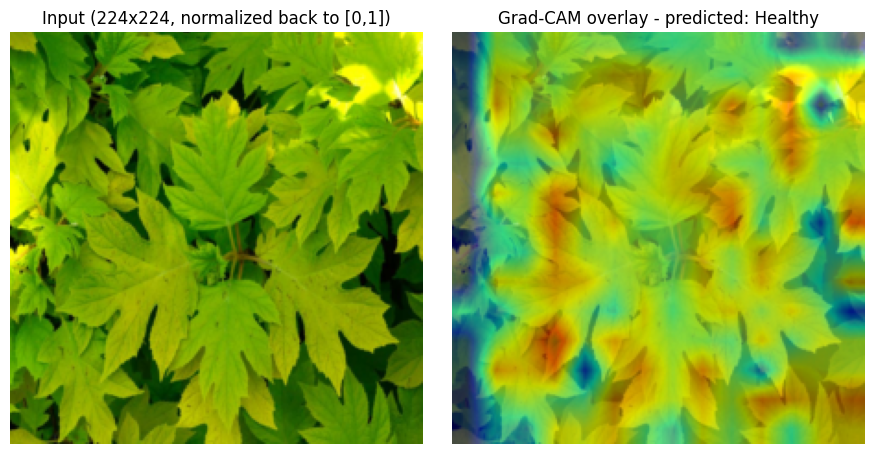

,class,probability (%),predicted
0,Aphids,0.1,False
1,Army Worm,0.0,False
2,Bacterial Blight,0.1,False
3,Cotton Boll Rot,0.1,False
4,Green Cotton Boll,0.1,False
5,Healthy,99.4,True
6,Powdery Mildew,0.1,False
7,Target Spot,0.1,False


saved /content/cottonleafnet_prediction.csv


In [ ]:
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(rgb_img)
axes[0].set_title("Input (224x224, normalized back to [0,1])")
axes[0].axis("off")
axes[1].imshow(cam_image)
axes[1].set_title(f"Grad-CAM overlay - predicted: {predicted_class}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

df = pd.DataFrame({"class": class_names, "probability (%)": probabilities_percent})
df["predicted"] = df["class"] == predicted_class
display(df)
df.to_csv("/content/cottonleafnet_prediction.csv", index=False)
print("saved /content/cottonleafnet_prediction.csv")

Probability bar chart for all 8 classes.

**確率の棒グラフ:** 8 クラス全ての予測確率。

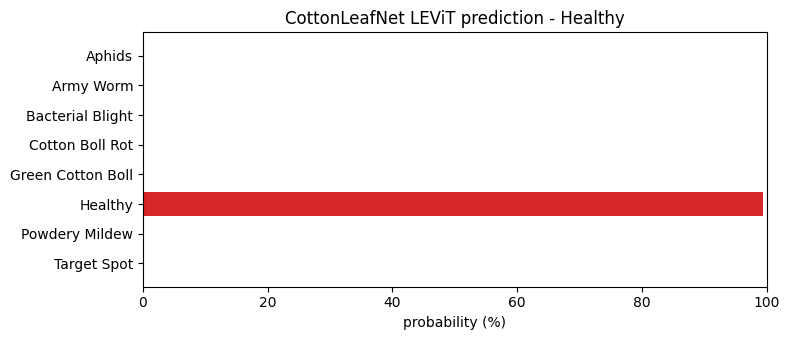

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#d62728" if p else "#7f7f7f" for p in df["predicted"]]
ax.barh(df["class"][::-1], df["probability (%)"][::-1], color=colors[::-1])
ax.set_xlabel("probability (%)")
ax.set_xlim(0, 100)
ax.set_title(f"CottonLeafNet LEViT prediction - {predicted_class}")
plt.tight_layout()
plt.show()

## 8. Interpretation, validation record, references

**What was executed here (recorded from the actual run):** the pinned 28.3 MB CottonLeafNet weight passed the SHA-256 check; a single deterministic sample from the author's CottonLeafNet Kaggle dataset was classified by the author's `levit_128s` inference code, and Grad-CAM was computed at the author's exact target layer. The predicted class and probabilities printed above are this run's actual outputs.

**Limitations:** one image is a demonstration, not a reproduction of the paper's 10-fold cross-validated metrics (augmented F1 99.80 ± 0.62 on CottonLeafNet). Training, the other three datasets (SAR-CLD-2024, CottonFabricImageBD, FabricSpotDefect), robustness perturbations, and the Flask web UI are out of scope.

**Provenance:** paper DOI 10.1016/j.isci.2025.114411 (open-access PMC version of record); author code commit `ad0ba908931fd283173644b7f28b22a37ecd8af8` (MIT); sample from `rezaullhaque/cottonleafnet-dataset` (author's dataset); weight `CottonLeafNet_levit_model.pth`, git blob `0313c7e0…f38af0aa`, SHA-256 `8f12aae2…391bd`. Grad-CAM via `pytorch_grad_cam` (Gildenblat et al.).

**検証の記録:** 固定コミットの重み（SHA-256 検証済み）と著者の推論コードをそのまま用い、決定論的サンプル 1 枚に対する分類と Grad-CAM を実行しました。単一サンプルのデモであり、論文の交差検証結果の再現ではありません。学習・他 3 データセット・頑健性実験・Flask UI は範囲外です。